# Disease Trend Analysis - Age & Gender

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Data Preparation

In [2]:
df = pd.read_csv("../data/cleaned/cleaned_dataset.csv")

df.head()


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,change,diabetesMed,readmitted,doctor_id,department,admission_date,bed_occupancy,location,patient_satisfaction,length_of_stay
0,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,Ch,Yes,>30,DOC_8270,General Medicine,2007-10-03,90,"New York, NY",2,3
1,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,Yes,NO,DOC_1860,Cardiology,2005-11-13,82,"New York, NY",1,2
2,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,Ch,Yes,NO,DOC_6390,Neurology,2002-04-11,59,"Chicago, IL",4,2
3,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,Ch,Yes,NO,DOC_6191,Endocrinology,2003-06-26,85,"Chicago, IL",5,1
4,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,Yes,>30,DOC_6734,Cardiology,2002-08-19,94,"Houston, TX",5,3


In [3]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted',
 'doctor_id',
 'department',
 'admission_date',
 'bed_occupancy',
 'location',
 'patient_satisfaction',
 'length_of_stay']

In [4]:
# Dataset Shape
print("Rows, Columns:", df.shape)

# Data Types
df.info()

Rows, Columns: (98053, 54)
<class 'pandas.DataFrame'>
RangeIndex: 98053 entries, 0 to 98052
Data columns (total 54 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   encounter_id              98053 non-null  int64
 1   patient_nbr               98053 non-null  int64
 2   race                      98053 non-null  str  
 3   gender                    98053 non-null  str  
 4   age                       98053 non-null  str  
 5   admission_type_id         98053 non-null  int64
 6   discharge_disposition_id  98053 non-null  int64
 7   admission_source_id       98053 non-null  int64
 8   time_in_hospital          98053 non-null  int64
 9   num_lab_procedures        98053 non-null  int64
 10  num_procedures            98053 non-null  int64
 11  num_medications           98053 non-null  int64
 12  number_outpatient         98053 non-null  int64
 13  number_emergency          98053 non-null  int64
 14  number_inpatient      

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

max_glu_serum    92845
A1Cresult        81860
dtype: int64

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,bed_occupancy,patient_satisfaction,length_of_stay
count,9.805300e+04,9.805300e+04,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000
mean,1.658294e+08,5.484792e+07,2.025813,3.753368,5.776692,4.421976,43.148073,1.350749,16.119650,0.376378,0.202462,0.646864,7.512060,74.467818,3.005150,4.421976
std,1.024322e+08,3.866175e+07,1.450117,5.309392,4.071640,2.993074,19.712033,1.708506,8.108476,1.283359,0.942892,1.271020,1.832497,14.439626,1.414929,2.993074
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000,50.000000,1.000000,1.000000
25%,8.528566e+07,2.350234e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,11.000000,0.000000,0.000000,0.000000,6.000000,62.000000,2.000000,2.000000
50%,1.533019e+08,4.687790e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,74.000000,3.000000,4.000000
75%,2.305007e+08,8.800306e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,87.000000,4.000000,6.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,99.000000,5.000000,14.000000


## Age Group Analysis

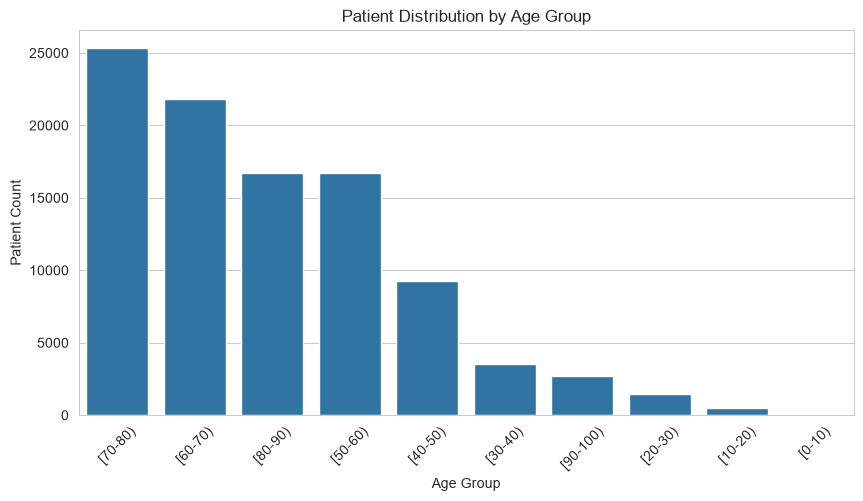

In [8]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="age",
    order=df["age"].value_counts().index
)

plt.title("Patient Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Patient Count")

plt.xticks(rotation=45)

plt.show()

## Gender Analysis

C:\Users\SK COMPUTERS\AppData\Local\Temp\ipykernel_12200\2899393475.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


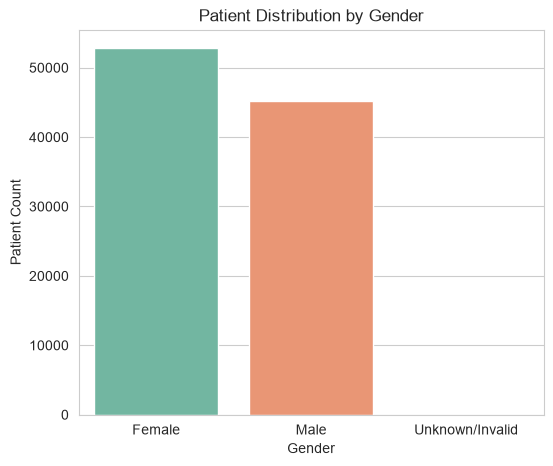

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="gender",
    palette="Set2"
)

plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Patient Count")

plt.show()

In [13]:
age_disease = pd.crosstab(
    df["age"],
    df["diag_1"]
)

age_disease

diag_1,10,11,110,112,114,115,117,131,133,135,...,V54,V55,V56,V57,V58,V60,V63,V66,V67,V71
age,,,,,,,,,,,,,,,,,,,,,
[0-10),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
[10-20),0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
[20-30),0,0,0,1,0,0,1,0,0,2,...,0,0,0,4,1,0,0,0,0,0
[30-40),0,0,0,1,0,1,0,0,0,1,...,0,1,1,13,5,0,0,0,0,0
[40-50),0,2,0,7,0,0,1,1,0,8,...,1,7,2,55,24,0,0,0,0,1
[50-60),0,4,0,7,0,1,3,0,0,8,...,6,13,5,140,59,0,0,0,0,1
[60-70),1,1,0,11,0,0,2,1,0,3,...,11,14,3,253,81,1,3,2,0,0
[70-80),0,2,2,20,1,0,0,0,0,4,...,11,23,3,433,28,0,5,0,1,5
[80-90),0,1,0,20,0,0,1,0,1,0,...,9,8,2,252,24,0,0,0,0,1


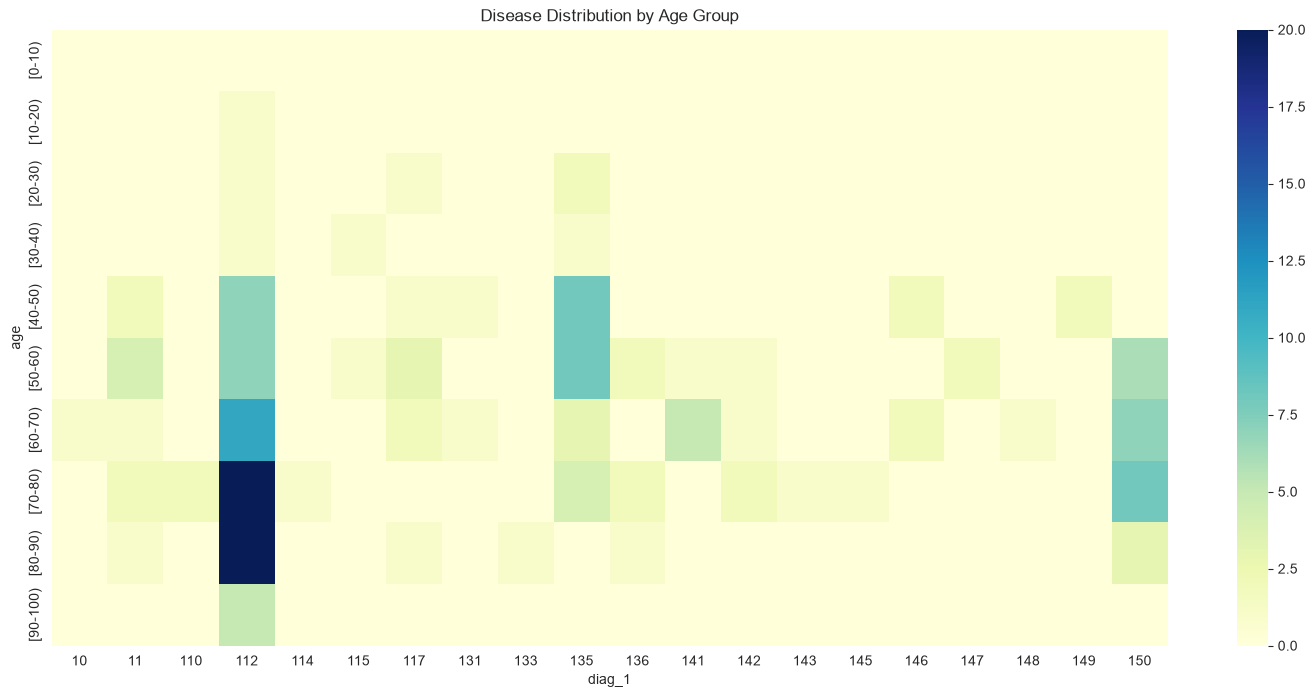

In [ ]:
plt.figure(figsize=(18,8))

sns.heatmap(
    age_disease.iloc[:, :20],
    cmap="YlGnBu"
)

plt.title("Heatmap of Disease Distribution Across Age Groups")

plt.show()

In [15]:
gender_disease = pd.crosstab(
    df["gender"],
    df["diag_1"]
)

gender_disease

diag_1,10,11,110,112,114,115,117,131,133,135,...,V54,V55,V56,V57,V58,V60,V63,V66,V67,V71
gender,,,,,,,,,,,,,,,,,,,,,
Female,0,2,1,44,1,2,2,2,0,23,...,30,38,9,668,91,0,3,0,0,5
Male,1,8,1,29,0,0,6,0,1,3,...,10,31,7,511,132,1,5,2,1,4
Unknown/Invalid,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


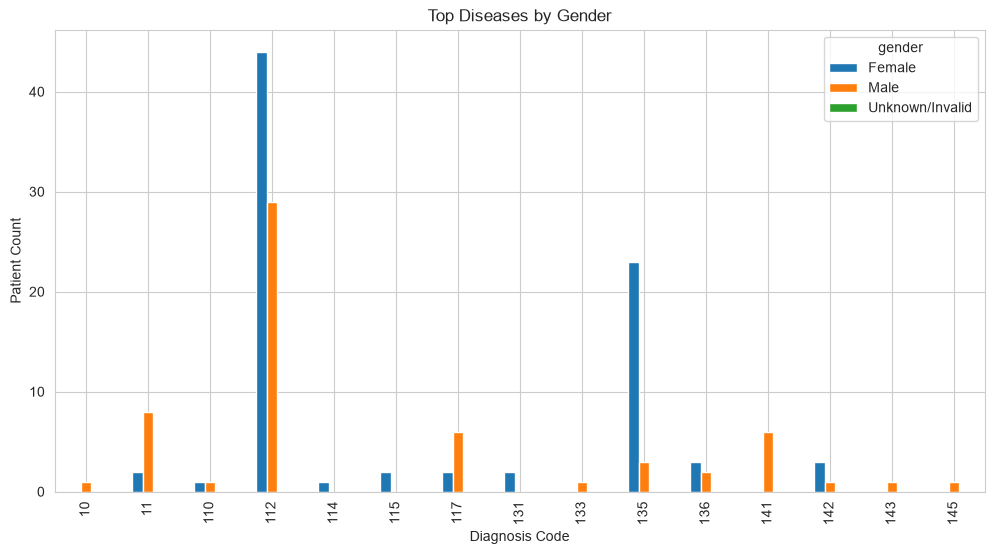

In [16]:
gender_disease.T.head(15).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top Diseases by Gender")
plt.xlabel("Diagnosis Code")
plt.ylabel("Patient Count")

plt.show()

## Key Findings

- Patient records include multiple age groups and both genders.
- Older age groups show a higher number of hospital admissions.
- Disease diagnosis codes vary across different age groups.
- Male and female patients exhibit different disease distributions.

## Key Insights

- The dataset contains patients from multiple age groups.
- Older age groups account for a larger proportion of hospital admissions.
- Male and female patients show different distributions across diagnosis codes.
- Several diagnosis codes occur more frequently than others, indicating common disease patterns.